In [1]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, MaxPooling2D, Flatten, BatchNormalization, Conv2D, Dropout

import matplotlib.pyplot as plt
from keras.applications.vgg16 import VGG16
import matplotlib.pyplot as plt

In [2]:
!kaggle datasets download bhavikjikadara/dog-and-cat-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
100% 775M/775M [00:38<00:00, 21.1MB/s]



In [6]:
!unzip -q dataset.zip -d /content/dataset

In [7]:
from pathlib import Path

# Parent folder containing cat/ and dog/
data_dir = Path("/content/dataset/PetImages")

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

bad_files = []

for file in data_dir.rglob("*"):
    if file.suffix.lower() in extensions:
        try:
            raw = tensorflow.io.read_file(str(file))
            img = tensorflow.io.decode_image(
                raw,
                channels=3,
                expand_animations=False
            )
            img = tensorflow.ensure_shape(img, [None, None, 3])
            _ = img.numpy()

        except Exception as e:
            bad_files.append(file)

print(f"Found {len(bad_files)} TensorFlow-unreadable files.")

# Delete them
for file in bad_files:
    file.unlink()

Found 7 TensorFlow-unreadable files.


In [8]:
# image data loading

train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/dataset/PetImages',
    label_mode='int',
    labels='inferred',
    batch_size=32,
    image_size=(128, 128),
    validation_split=0.2,
    subset='training',
    seed=149
)

test_ds = keras.utils.image_dataset_from_directory(
    directory='/content/dataset/PetImages',
    label_mode='int',
    labels='inferred',
    batch_size=32,
    image_size=(128, 128),
    validation_split=0.2,
    subset='validation',
    seed=149
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [9]:
def normalize(img, label):
    # img = img/255.0
    img = tensorflow.cast(img/255.0, tensorflow.float32)
    return img, label

train_ds = train_ds.map(normalize)
test_ds = test_ds.map(normalize)

## Transfer Learning (VGG16)

### Feature Engineering

In [10]:
conv_base = VGG16(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
conv_base.trainable = False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,772,481 (60.17 MB)

 Trainable params: 1,057,409 (4.03 MB)

 Non-trainable params: 14,715,072 (56.13 MB)

In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [13]:
history = model.fit(train_ds, validation_data=test_ds, epochs=25)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 101ms/step - accuracy: 0.8681 - loss: 0.3005 - val_accuracy: 0.8864 - val_loss: 0.2559
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.9021 - loss: 0.2341 - val_accuracy: 0.8862 - val_loss: 0.2677
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9124 - loss: 0.2066 - val_accuracy: 0.9002 - val_loss: 0.2368
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9158 - loss: 0.1992 - val_accuracy: 0.8970 - val_loss: 0.2457
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9293 - loss: 0.1725 - val_accuracy: 0.8884 - val_loss: 0.2766
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9392 - loss: 0.1542 - val_accuracy: 0.8962 - val_loss: 0.2621
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9447 - loss: 0.1396 - val_accuracy: 0.8862 - val_loss: 0.3156
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9485 - loss: 0.1262 -

[]

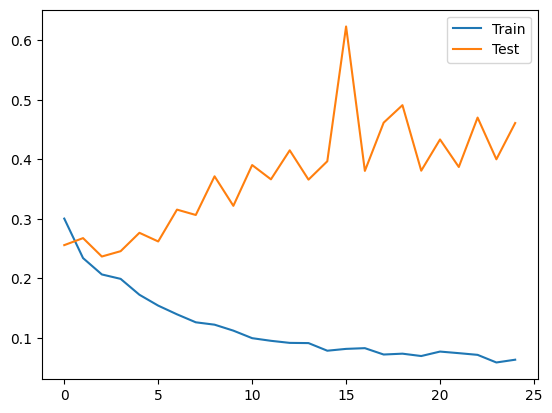

In [14]:
plt.plot(history.history['loss'], label="Train")
plt.plot(history.history['val_loss'], label='Test')

plt.legend()
plt.plot()

[]

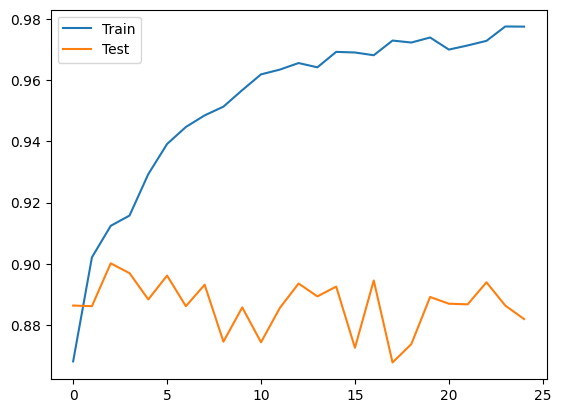

In [15]:
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label='Test')

plt.legend()
plt.plot()